# B3 · Transformer Attention Mechanism

Scaled dot-product attention from scratch (topic **B3** of the project catalog):
profile a CPU transformer block, find the bottleneck, and replace it — only it —
with progressively better CUDA kernels.

| Version | Attention implementation | Key idea |
|---|---|---|
| `CpuPipeline` | torch matmul + softmax | all-PyTorch reference: profiling *and* CPU timing baseline, every stage vectorized (MKL) |
| `GpuV1` | cuBLAS matmuls + 3-pass softmax | dispatch the GEMMs to the library; keep a naive softmax kernel |
| `GpuV2` | cuBLAS matmuls + online softmax | same GEMMs; the one-pass softmax is the surviving hand-written rung |
| `GpuV3` | fused FlashAttention-1 forward | one kernel, resident Q tile, online softmax — the N×N matrix never exists |

Everything except attention — embedding, projections, norms, FFN — stays in
PyTorch on the CPU (*partial GPU principle*): only the profiled bottleneck moves.

In [1]:
# On Colab: clone the repo, then `pip install numba` if missing.
import os
import sys

# sequential CPU baseline by configuration, set before torch loads: no AVX
# dispatch in ATen, GEMMs at MKL's minimum ISA (SSE2 is the x86-64 floor --
# torch exposes no true scalar mode), one thread (set after import below)
os.environ["ATEN_CPU_CAPABILITY"] = "default"
os.environ["MKL_ENABLE_INSTRUCTIONS"] = "SSE2"
for p in ("../src", "src", "gpt/src"):
    if p not in sys.path:
        sys.path.insert(0, p)

import torch
from numba import cuda

from cpu_baseline import CpuPipeline
from gpu_v1 import GpuV1
from gpu_v2 import GpuV2
from gpu_v3 import GpuV3
import bench

torch.set_num_threads(1)  # single-thread CPU baseline: SIMD, no thread parallelism
print(f"torch {torch.__version__} | CUDA available: {cuda.is_available()} | cpu threads: {torch.get_num_threads()}")

torch 2.12.1+cu130 | CUDA available: True | cpu threads: 1


## Stage 1 — CPU baseline and bottleneck analysis

One CPU model does both Stage-1 jobs. `CpuPipeline` runs every stage —
attention included — as plain torch ops made *sequential by
configuration*, not by rewriting: one thread (`torch.set_num_threads(1)`),
ATen dispatch capped at its baseline ISA (`ATEN_CPU_CAPABILITY=default`)
and MKL at SSE2 — the narrowest execution torch can be told to use, while
the code stays three library calls. The
`torch.profiler.record_function` shares reflect *algorithmic* cost, not
interpreter overhead; and its attention wall time doubles as the timing
baseline the GPU versions must beat — competent CPU code, not a strawman.

Attention is the only $O(N^2 D)$ step in the block; projections and FFN are
$O(N D^2)$, linear in N. Chart 1 shows exactly that scaling: the attention
share starts small at $N = 64$, where the FFN dominates, grows through the
FLOP-count crossover at $N \approx 5.5D \approx 2800$, and owns the forward
pass by the top of the sweep. The step that scales worst is the GPU target.

In [2]:
# Correctness gate: the CPU baseline must match torch's SDPA before it can
# serve as the profiling / timing reference.
torch.manual_seed(0)
cpu_model = CpuPipeline().eval()
x = torch.randint(0, 1000, (2, 16))
with torch.no_grad():
    # unfused matmul / softmax / matmul vs fused SDPA
    torch.testing.assert_close(cpu_model(x), bench.sdpa_reference(cpu_model, x),
                               atol=1e-4, rtol=1e-3)
print("CpuPipeline matches torch.nn.functional.scaled_dot_product_attention")

CpuPipeline matches torch.nn.functional.scaled_dot_product_attention


/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/torch/profiler/profiler.py:272: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(
USDT:2026-08-05 09:18:36 903506:903506 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 09:18:36 903506:903506 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 09:18:36 903506:903506 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 09:18:36 903506:903506 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 09:18:36 903506:903506 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 09:18:36 903506:903506 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 09:18:36 903506:903506 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-05 09:18:36 903506:903506 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 09:18:36 903506:903506 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-05 09:18:36 903506:903506 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-05 09:18:36 903506:903506 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-05 09:18:36 903506:903506 ActivityProfilerController.cpp:455] profiler_stop


...

USDT:2026-08-05 09:18:38 903506:903506 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-05 09:18:41 903506:903506 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-05 09:18:43 903506:903506 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-05 09:18:52 903506:903506 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-05 09:19:01 903506:903506 ActivityProfilerController.cpp:455] profiler_stop


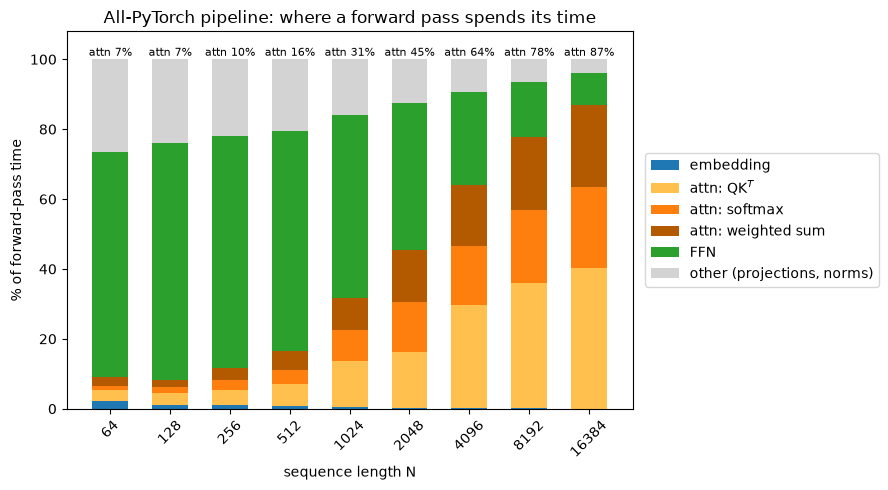

In [3]:
# Chart 1 -- share of forward-pass time per step (all-PyTorch pipeline)
import matplotlib.pyplot as plt
import numpy as np

PROFILE_LENS = [2 ** x for x in range(6, 15)]
pcts = [bench.step_percentages(cpu_model, n) for n in PROFILE_LENS]

parts = bench.STEPS + ["other"]
names = {"1_embedding": "embedding", "2a_qk_matmul": "attn: QK$^T$",
         "2b_softmax": "attn: softmax", "2c_value_weighted_sum": "attn: weighted sum",
         "3_ffn": "FFN", "other": "other (projections, norms)"}
colors = {"1_embedding": "tab:blue", "2a_qk_matmul": "#ffc04d", "2b_softmax": "tab:orange",
          "2c_value_weighted_sum": "#b35a00", "3_ffn": "tab:green", "other": "lightgray"}

fig, ax = plt.subplots(figsize=(9, 5))
xpos = np.arange(len(PROFILE_LENS))
bottom = np.zeros(len(PROFILE_LENS))
for part in parts:
    vals = np.array([p[part] for p in pcts])
    ax.bar(xpos, vals, 0.6, bottom=bottom, label=names[part], color=colors[part])
    bottom += vals

for xi, p in zip(xpos, pcts):  # annotate total attention share
    attn = sum(p[s] for s in bench.ATTN_STEPS)
    ax.text(xi, 101, f"attn {attn:.0f}%", ha="center", fontsize=8)

ax.set_xticks(xpos, PROFILE_LENS, rotation=45)
ax.set_xlabel("sequence length N")
ax.set_ylabel("% of forward-pass time")
ax.set_ylim(0, 108)
ax.set_title("All-PyTorch pipeline: where a forward pass spends its time")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

## Stage 2 — GPU versions

Three versions, one lesson each: V1 is the straight port — correct, massively
parallel, and wasteful with memory traffic; V2 shows where kernel speed
actually lives: data reuse; V3 changes the algorithm so the traffic V2 was
economising never exists at all.

**V1 — cuBLAS matmuls + naive three-pass softmax** (`gpu_v1.py`): the two
matmuls dispatch to the library (`torch.mm` → cuBLAS SGEMM, with the
$1/\sqrt{D}$ scale folded into the cheap $O(ND)$ operand rather than a pass
over the N×N output); the hand-written part is the softmax — one block per
row, three reads of the row (max, sum, write). Every intermediate,
including the full N×N score matrix, still round-trips through global
memory between launches.

**V2 — cuBLAS matmuls + online softmax** (`gpu_v2.py`): same launch
structure; the upgrade that survives library dispatch is the softmax.
`_softmax_online` keeps a running (max, sum) pair per thread, rescaled
whenever the max moves — the log-sum-exp trick — so both statistics come
out of **one** coalesced read of the row where V1 pays three. Still
materialises the N×N matrix.

**V3 — fused FlashAttention-1 forward** (`gpu_v3.py`): the whole step in one
kernel, and the $N \times N$ score matrix never exists in any memory. Each
block stages its 16-row Q tile in shared memory *once* and keeps it resident
while sweeping the K/V tiles — Q traffic drops from $O(N^2 D)$ to $O(N D)$.
Per 16×16 tile: the score tile $S = QK^T/\sqrt{D}$ is a shared-memory block
matmul (K and V staged chunk by chunk with exactly V2's tiling idiom — no
prefetching, no unrolling); then Algorithm 1 of the FlashAttention paper
runs verbatim — the tile's row max $\tilde{m}$ and sum $\tilde{l}$ merge
into the running $(m, l)$, and the output block is rescaled *and
renormalised* on the spot, so it always holds the exact softmax-weighted sum
of every key seen so far. Where V2 economised the N×N traffic, V3 deletes
it — at the price of one rescale-divide per tile, which FA-2 later showed
how to defer.

**Correctness contract:** every version must match
`torch.nn.functional.scaled_dot_product_attention` within 1e-4
(checked below and in `tests/test_correctness.py`).

In [4]:
# End-to-end correctness of each GPU version against torch SDPA
if cuda.is_available():
    x = torch.randint(0, 1000, (1, 128))
    for cls in (GpuV1, GpuV2, GpuV3):
        model = cls().eval()
        with torch.no_grad():
            torch.testing.assert_close(model(x), bench.sdpa_reference(model, x),
                                       atol=1e-4, rtol=1e-3)
        print(f"{cls.__name__}: matches torch SDPA within 1e-4")
else:
    print("No CUDA device -- skipping GPU correctness checks")

GpuV1: matches torch SDPA within 1e-4


GpuV2: matches torch SDPA within 1e-4


/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 8 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


GpuV3: matches torch SDPA within 1e-4


### Distribution shift — the bottleneck moves back

Same buckets for all four pipelines: attention as a single step, since the
GPU versions don't split it into sub-steps (and their attention time includes
the CPU↔GPU transfers — the honest cost of the swap); the all-PyTorch panel
reuses Chart 1's measurements. Moving attention to the GPU flips Chart 1: the
$O(N^2)$ step drops out of the distribution and the forward pass belongs to
the linear PyTorch steps again — until the $O(N^2)$ kernel time starts
creeping back in at the top of the sweep, the same scaling argument one level
down. V1, V2 and V3 differ only in the attention band, so each faster kernel
is directly visible as a thinner orange stripe.

/home/ubuntu/gpt/.venv/lib/python3.12/site-packages/numba/cuda/dispatcher.py:537: NumbaPerformanceWarning: Grid size 64 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
USDT:2026-08-05 09:19:02 903506:903506 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 09:19:02 903506:903506 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 09:19:02 903506:903506 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 09:19:02 903506:903506 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 09:19:02 903506:903506 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 09:19:02 903506:903506 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 09:19:02 903506:903506 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 09:19:02 903506:903506 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-05 09:19:03 903506:903506 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 09:19:03 903506:903506 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 09:19:03 903506:903506 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-05 09:19:03 903506:903506 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-05 09:19:03 903506:903506 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-05 09:19:03 903506:903506 ActivityProfilerController.cpp:455] profiler_stop


...

USDT:2026-08-05 09:19:13 903506:903506 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-05 09:19:14 903506:903506 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-05 09:19:15 903506:903506 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-05 09:19:18 903506:903506 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-05 09:19:20 903506:903506 ActivityProfilerController.cpp:455] profiler_stop


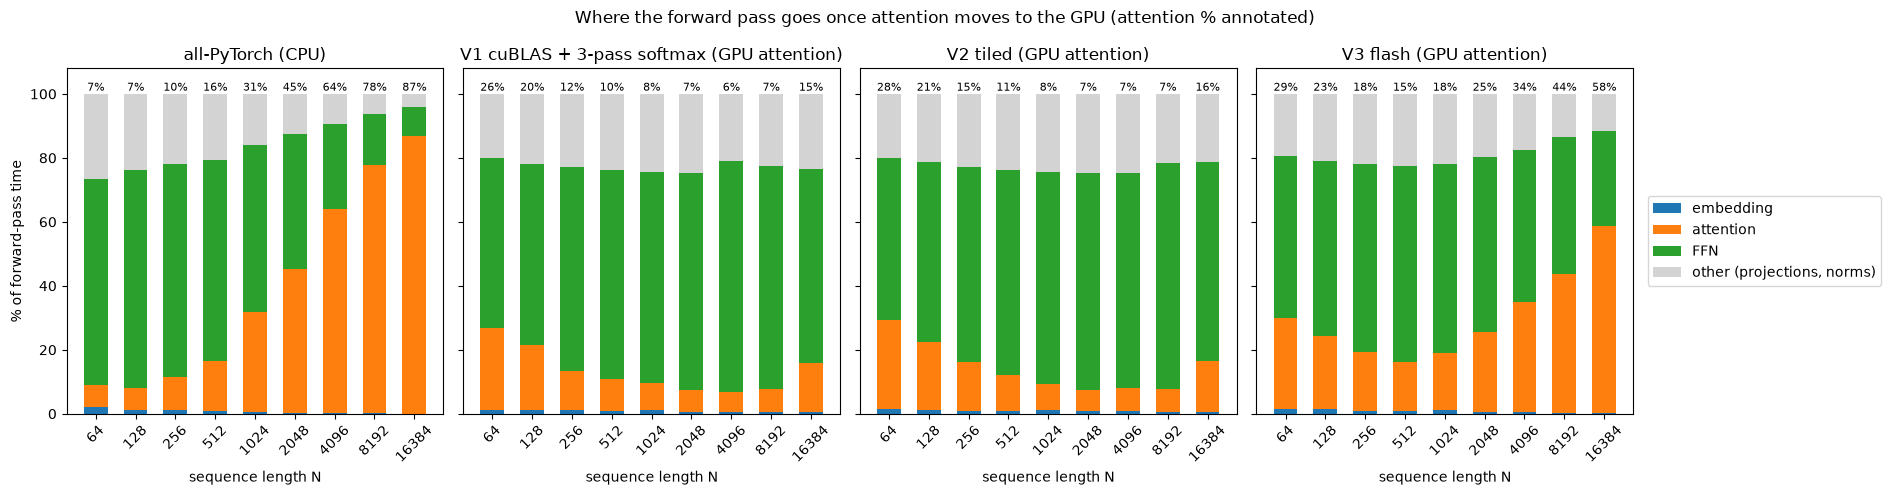

In [5]:
# Chart 1b -- step-time distribution per pipeline (coarse buckets, all comparable)
if cuda.is_available():
    # torch panel reuses Chart 1's profile: the sub-steps sum to the attention total
    dist = {"all-PyTorch (CPU)": [
        {"1_embedding": p["1_embedding"],
         "2_attention_total": sum(p[s] for s in bench.ATTN_STEPS),
         "3_ffn": p["3_ffn"], "other": p["other"]} for p in pcts]}
    for title, m in (("V1 cuBLAS + 3-pass softmax (GPU attention)", GpuV1().eval()),
                     ("V2 tiled (GPU attention)", GpuV2().eval()),
                     ("V3 flash (GPU attention)", GpuV3().eval())):
        dist[title] = [bench.step_percentages(m, n, steps=bench.STEPS_TOTAL)
                       for n in PROFILE_LENS]
    torch.cuda.empty_cache()  # drop the dead N x N blocks the GPU passes leave cached

    parts = bench.STEPS_TOTAL + ["other"]
    names = {"1_embedding": "embedding", "2_attention_total": "attention",
             "3_ffn": "FFN", "other": "other (projections, norms)"}
    colors = {"1_embedding": "tab:blue", "2_attention_total": "tab:orange",
              "3_ffn": "tab:green", "other": "lightgray"}

    fig, axes = plt.subplots(1, 4, figsize=(19, 5), sharey=True)
    xpos = np.arange(len(PROFILE_LENS))
    for ax, (title, ps) in zip(axes, dist.items()):
        bottom = np.zeros(len(PROFILE_LENS))
        for part in parts:
            vals = np.array([p[part] for p in ps])
            ax.bar(xpos, vals, 0.6, bottom=bottom, label=names[part], color=colors[part])
            bottom += vals
        for xi, p in zip(xpos, ps):  # annotate the attention share
            ax.text(xi, 101, f"{p['2_attention_total']:.0f}%", ha="center", fontsize=8)
        ax.set_xticks(xpos, PROFILE_LENS, rotation=45)
        ax.set_xlabel("sequence length N")
        ax.set_title(title)
        ax.set_ylim(0, 108)
    axes[0].set_ylabel("% of forward-pass time")
    axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    plt.suptitle("Where the forward pass goes once attention moves to the GPU (attention % annotated)")
    plt.tight_layout()
    plt.show()
else:
    print("No CUDA device -- skipping the combined step-share chart")

## Benchmark — attention step time

Timings cover the attention step only, on precomputed q, k, v. The GPU
columns *include* the CPU→GPU→CPU transfers — the true cost of swapping a
kernel into an otherwise-CPU pipeline. N sweeps the powers of two from $2^6$
to $2^{14}$ (64 → 16384), covering every spec checkpoint (128 / 512 / 2048)
and running well past the $N \approx 5.5D$ crossover where attention owns
the forward pass. The CPU baseline is the same attention as three torch ops on a single,
minimum-ISA CPU thread (sequential by configuration) — one warm profiled
pass per point, which also
yields the sub-step times reused as Chart 2's baselines; a calibration
pass projects the top of the sweep and warns when a sequence length is
not feasible single-threaded (time or RAM). The top
of the sweep is a memory wall, not a time wall: the unfused N×N score and
weight matrices cost ~2–3 GB of RAM at N = 16384 and 4× that at the next
doubling, and V1/V2's GPU intermediates track the same growth (Chart 4).

In [6]:
SEQ_LENS = [2 ** x for x in range(6, 15)]

if cuda.is_available():
    classes = {"V1 cuBLAS + 3-pass softmax": GpuV1,
               "V2 cuBLAS + online softmax": GpuV2,
               "V3 flash fused": GpuV3,
               }
    times = bench.bench_attention(classes, SEQ_LENS, reps=3)
    times["torch SDPA (GPU)"] = [bench.sdpa_gpu_ms(cpu_model, n, reps=3) for n in SEQ_LENS]
    torch.cuda.empty_cache()  # drop cached blocks so the sweep leaves no footprint

    # CPU baseline: the same attention as three vectorized torch/MKL ops on
    # the same cores — one warm profiled pass per point yields the sub-step
    # times (Chart 2's baselines) and their sum, the CPU column
    cpu_model.attention(*bench._qkv(cpu_model, 64))  # warm MKL / thread pool

    # feasibility guard: the baseline is one thread doing O(N^2 D) work with
    # 3 N x N fp32 intermediates -- calibrate one pass, project the sweep top
    import os
    cal_ms = bench.attention_ms(cpu_model, 1024, reps=1)
    proj_s = cal_ms * (SEQ_LENS[-1] / 1024) ** 2 / 1e3
    ram = os.sysconf("SC_PHYS_PAGES") * os.sysconf("SC_PAGE_SIZE")
    need = 3 * SEQ_LENS[-1] ** 2 * 4
    if proj_s > 30 or need > 0.6 * ram:
        print(f"WARNING: N = {SEQ_LENS[-1]} may not be feasible single-threaded: "
              f"projected ~{proj_s:.0f} s per CPU attention pass, "
              f"~{need / 1e9:.1f} GB of {ram / 1e9:.0f} GB RAM for the intermediates")

    cpu_steps = [bench.attention_step_ms(cpu_model, n) for n in SEQ_LENS]
    times = {"CPU": [sum(d.values()) for d in cpu_steps], **times}

    header = f"{'N':>6} " + "".join(f"{name:>28}" for name in times)
    print(header + "\n" + "-" * len(header))
    for i, n in enumerate(SEQ_LENS):
        print(f"{n:>6} " + "".join(f"{times[name][i]:>25.2f} ms" for name in times))
else:
    print("No CUDA device -- skipping the GPU benchmark")

COLORS = {"CPU": "tab:red",
          "V1 cuBLAS + 3-pass softmax": "tab:blue", "V2 cuBLAS + online softmax": "tab:orange",
          "V3 flash fused": "tab:green", "torch SDPA (GPU)": "gray"}

USDT:2026-08-05 09:19:35 903506:903506 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 09:19:35 903506:903506 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 09:19:35 903506:903506 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 09:19:35 903506:903506 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 09:19:35 903506:903506 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 09:19:35 903506:903506 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 09:19:35 903506:903506 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 09:19:35 903506:903506 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 09:19:35 903506:903506 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05 09:19:35 903506:903506 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 09:19:35 903506:903506 ActivityProfilerController.cpp:415] profiler_start
USDT:2026-08-05

USDT:2026-08-05 09:19:35 903506:903506 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-05 09:19:36 903506:903506 ActivityProfilerController.cpp:455] profiler_stop
USDT:2026-08-05 09:19:36 903506:903506 ActivityProfilerController.cpp:415] profiler_start


USDT:2026-08-05 09:19:38 903506:903506 ActivityProfilerController.cpp:455] profiler_stop


USDT:2026-08-05 09:19:38 903506:903506 ActivityProfilerController.cpp:415] profiler_start


     N                          CPU  V1 cuBLAS + 3-pass softmax  V2 cuBLAS + online softmax              V3 flash fused            torch SDPA (GPU)
---------------------------------------------------------------------------------------------------------------------------------------------------
    64                      0.75 ms                     1.04 ms                     1.01 ms                     1.30 ms                     0.57 ms
   128                      0.81 ms                     1.25 ms                     1.23 ms                     1.71 ms                     0.72 ms
   256                      2.07 ms                     1.69 ms                     1.70 ms                     2.53 ms                     1.11 ms
   512                      6.47 ms                     2.63 ms                     2.60 ms                     4.39 ms                     1.88 ms
  1024                     24.11 ms                     3.71 ms                     3.76 ms                    1

USDT:2026-08-05 09:19:46 903506:903506 ActivityProfilerController.cpp:455] profiler_stop


## Attention kernel timing — compute only

How fast are the kernels once the transfers are taken out of the picture?
Following the HW02 methodology: **device-resident timing with CUDA events**, so
the timed region is pure compute — no CPU→GPU→CPU copy. This isolates kernel
speed from the pipeline-boundary tax that the end-to-end sweep pays.

In [7]:
# Kernel-only timing sweep (CUDA events, device-resident)
if cuda.is_available():
    specs = bench.gpu_specs()
    print(f"GPU: {specs['name']} | {specs['sm']} SMs")

    kmodels = {"V1 cuBLAS + 3-pass softmax": GpuV1().eval(),
               "V2 cuBLAS + online softmax": GpuV2().eval(),
               "V3 flash fused": GpuV3().eval(),
               }
    ktimes = {name: [bench.attention_kernel_ms(m, n, reps=10) for n in SEQ_LENS]
              for name, m in kmodels.items()}
    ktimes["torch SDPA (GPU)"] = [bench.sdpa_kernel_ms(cpu_model, n, reps=10)
                                  for n in SEQ_LENS]
    # per-step kernel times (QK^T, softmax, weighted sum) for Chart 3 --
    # only the unfused versions expose the three step methods (V3 is one kernel)
    ksteps = {name: [bench.attention_kernel_step_ms(m, n, reps=10) for n in SEQ_LENS]
              for name, m in kmodels.items() if "_step_qkt" in type(m).__dict__}
    torch.cuda.empty_cache()  # drop the dead N x N blocks V1/V2 leave cached

    header = f"{'N':>6}" + "".join(f"{name:>30}" for name in ktimes)
    print("\n" + header + "   (kernel-only ms)\n" + "-" * len(header))
    for i, n in enumerate(SEQ_LENS):
        print(f"{n:>6}" + "".join(f"{ktimes[name][i]:>27.3f} ms" for name in ktimes))
else:
    print("No CUDA device -- skipping the kernel metrics")

GPU: Tesla T4 | 40 SMs



     N    V1 cuBLAS + 3-pass softmax    V2 cuBLAS + online softmax                V3 flash fused              torch SDPA (GPU)   (kernel-only ms)
------------------------------------------------------------------------------------------------------------------------------
    64                      0.624 ms                      0.515 ms                      0.629 ms                      0.187 ms
   128                      0.541 ms                      0.511 ms                      0.656 ms                      0.180 ms
   256                      0.534 ms                      0.519 ms                      1.043 ms                      0.189 ms
   512                      0.540 ms                      0.511 ms                      1.741 ms                      0.180 ms
  1024                      0.543 ms                      0.545 ms                      7.421 ms                      0.488 ms
  2048                      1.426 ms                      1.486 ms                     28.8

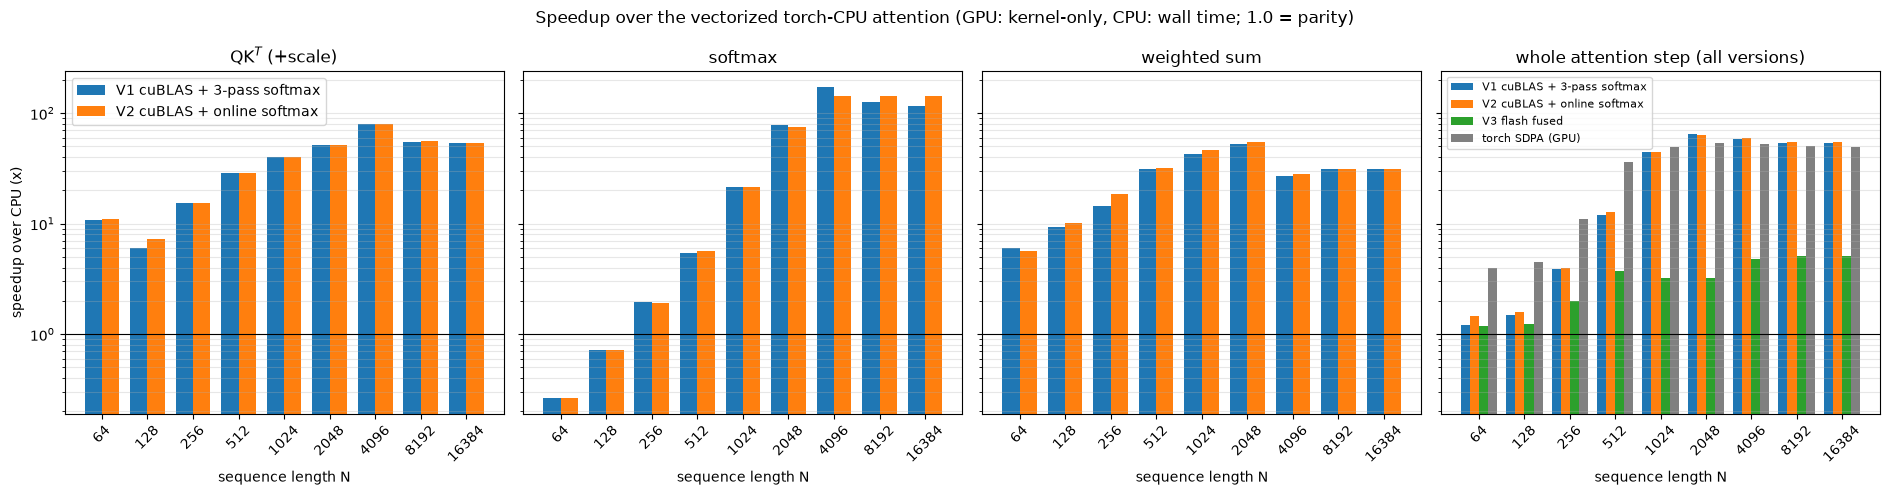

In [8]:
# Chart 2 -- speedup over the CPU baseline (vectorized torch): per sub-step
# for the unfused GPU versions, then the whole step for all four (V3 and
# torch SDPA are single fused kernels, so whole-step granularity only)
if cuda.is_available():
    step_names = {"2a_qk_matmul": "QK$^T$ (+scale)", "2b_softmax": "softmax",
                  "2c_value_weighted_sum": "weighted sum"}
    fig, axes = plt.subplots(1, 4, figsize=(19, 5), sharey=True)
    xpos = np.arange(len(SEQ_LENS))
    w = 0.76 / len(ksteps)
    offs = (np.arange(len(ksteps)) - (len(ksteps) - 1) / 2) * w
    for ax, (step, title) in zip(axes, step_names.items()):
        for off, (name, ks) in zip(offs, ksteps.items()):
            speedups = [c[step] / g[step] for c, g in zip(cpu_steps, ks)]
            ax.bar(xpos + off, speedups, w, color=COLORS[name], label=name)
        ax.set_yscale("log")
        ax.axhline(1.0, color="k", lw=0.8)
        ax.set_xticks(xpos, SEQ_LENS, rotation=45)
        ax.set_xlabel("sequence length N")
        ax.set_title(title)
        ax.grid(True, axis="y", which="both", alpha=0.3)

    ax = axes[-1]
    cpu_total = [sum(c.values()) for c in cpu_steps]
    w4 = 0.8 / len(ktimes)
    offs4 = (np.arange(len(ktimes)) - (len(ktimes) - 1) / 2) * w4
    for off, (name, kt) in zip(offs4, ktimes.items()):
        speedups = [c / g for c, g in zip(cpu_total, kt)]
        ax.bar(xpos + off, speedups, w4, color=COLORS[name], label=name)
    ax.set_yscale("log")
    ax.axhline(1.0, color="k", lw=0.8)
    ax.set_xticks(xpos, SEQ_LENS, rotation=45)
    ax.set_xlabel("sequence length N")
    ax.set_title("whole attention step (all versions)")
    ax.grid(True, axis="y", which="both", alpha=0.3)
    ax.legend(fontsize=8)

    axes[0].set_ylabel("speedup over CPU (x)")
    axes[0].legend()
    plt.suptitle("Speedup over the vectorized torch-CPU attention "
                 "(GPU: kernel-only, CPU: wall time; 1.0 = parity)")
    plt.tight_layout()
    plt.show()

## Memory bandwidth utilization — measured

Bytes from Nsight Compute (`dram__bytes.sum`: every transaction crossing the
DRAM boundary, refetches included — a one-off root-gated collection cached
in `dram_profile.json`), time from the boost-clock CUDA-event kernel sweep,
utilization = bytes / time / peak. The pairing matters: ncu locks the GPU
to base clocks, so its own durations run ~2.3× the event sweep — the byte
counts are clock-independent and ride on the honest time. The raw counts
and their ratio to the compulsory floor (Q, K, V in + out, once —
`bench.attention_bytes`) stay in the table.

What the numbers say: the unfused pipelines pay their N×N-materialisation
tax (88–110× the floor at N = 16384; V2's online softmax is exactly one
saved N² read, 1.1 GB less than V1) at real but unsaturated pressure —
~40–50% of the bus around N = 2048, settling to ~25–30% at the top of the
sweep, since GEMM time grows one power of N faster than the materialisation
bytes. V3 barely registers on this axis (~1%): its 3.6 GB moves through a
kernel ~10× longer — the fused trade in one number, a bus left idle because
the matmuls live in shared memory.

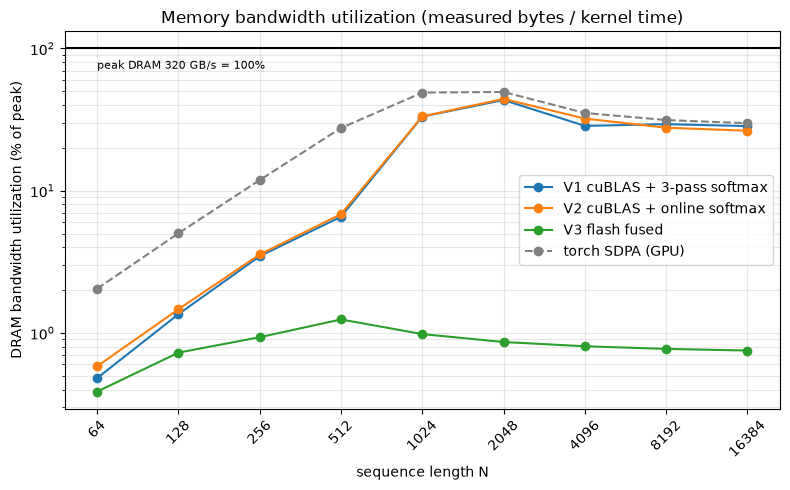

                   version      N    measured  floor x    GB/s  %peak
V1 cuBLAS + 3-pass softmax  16384    12967 MB    96.6x    91.1  28.5%
V2 cuBLAS + online softmax  16384    11842 MB    88.2x    84.5  26.4%
            V3 flash fused  16384     3578 MB    26.7x     2.4   0.8%
          torch SDPA (GPU)  16384    14767 MB   110.0x    95.4  29.8%


In [9]:
# Chart 3 -- DRAM bandwidth utilization: measured bytes (ncu, clock-
# independent) over kernel-only time (CUDA events, boost clocks), % of peak.
# Raw byte counts and floor ratios are in the table below.
if cuda.is_available():
    import json, os, subprocess, sys
    from pathlib import Path

    prof_path = Path("dram_profile.json")
    if not prof_path.exists():  # counters are root-gated: one-off sudo step
        cmd = ([] if os.geteuid() == 0 else ["sudo", "-n"]) + \
              [sys.executable, "src/dram_profile.py", "collect"]
        try:
            subprocess.run(cmd, check=True)
        except (subprocess.CalledProcessError, FileNotFoundError, PermissionError):
            print("no dram_profile.json and no counter access here -- run:")
            print("  sudo .venv/bin/python src/dram_profile.py collect")

    if prof_path.exists():
        prof = json.loads(prof_path.read_text())
        pnames = {"v1": "V1 cuBLAS + 3-pass softmax", "v2": "V2 cuBLAS + online softmax",
                  "v3": "V3 flash fused", "sdpa": "torch SDPA (GPU)"}
        bw = bench.gpu_specs()["bw_gbs"]
        fig, ax = plt.subplots(figsize=(8, 5))
        for key, rows in prof.items():
            name = pnames[key]
            tmap = dict(zip(SEQ_LENS, ktimes[name]))  # KeyError = stale json
            util = [100.0 * r["dram_bytes"] / (tmap[r["n"]] / 1e3) / 1e9 / bw
                    for r in rows]
            ax.plot([r["n"] for r in rows], util, marker="o", color=COLORS[name],
                    linestyle="--" if key == "sdpa" else "-", label=name)
        ax.axhline(100.0, color="k", lw=1.5)
        ax.text(SEQ_LENS[0], 72, f"peak DRAM {bw:.0f} GB/s = 100%", fontsize=8)
        ax.set_xscale("log", base=2)
        ax.set_yscale("log")
        ax.set_xticks(SEQ_LENS, SEQ_LENS, rotation=45)
        ax.set_xlabel("sequence length N")
        ax.set_ylabel("DRAM bandwidth utilization (% of peak)")
        ax.set_title("Memory bandwidth utilization (measured bytes / kernel time)")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

        print(f"{'version':>26} {'N':>6} {'measured':>11} {'floor x':>8} "
              f"{'GB/s':>7} {'%peak':>6}")
        for key, rows in prof.items():
            r = rows[-1]  # largest N
            t_s = ktimes[pnames[key]][-1] / 1e3
            gbs = r["dram_bytes"] / t_s / 1e9
            floor = bench.attention_bytes(cpu_model, r["n"])
            print(f"{pnames[key]:>26} {r['n']:>6} {r['dram_bytes'] / 1e6:>8.0f} MB "
                  f"{r['dram_bytes'] / floor:>7.1f}x {gbs:>7.1f} {100 * gbs * 1e9 / (bw * 1e9):>5.1f}%")
else:
    print("No CUDA device -- skipping the bandwidth chart")

## Memory footprint — the O(N²) wall

Traffic explains speed; footprint decides feasibility. The unfused versions
materialise the N×N score and weight matrices — 2·N²·4 bytes beyond the
inputs — while V3 streams tiles and allocates only the [N, D] output.
Footprint needs no CPU baseline, so this sweep runs past the timing cap
until the quadratic versions stop fitting on the card; the wall is measured
(torch allocator high-water mark, OOM caught), not modelled.

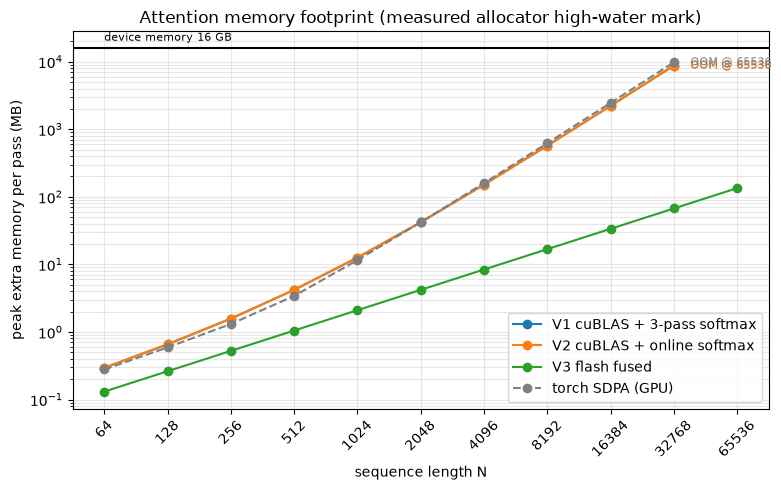

V1 cuBLAS + 3-pass softmax: fits to N = 32768, OOM at N = 65536
V2 cuBLAS + online softmax: fits to N = 32768, OOM at N = 65536
            V3 flash fused: fits to N = 65536
          torch SDPA (GPU): fits to N = 32768, OOM at N = 65536


In [10]:
# Chart 4 -- peak extra GPU memory of one attention pass, swept until the
# O(N^2) versions hit the card's capacity. None (OOM) ends a line.
if cuda.is_available():
    FOOT_LENS = [2 ** x for x in range(6, 17)]  # 64 .. 65536
    foot_models = {"V1 cuBLAS + 3-pass softmax": GpuV1(), "V2 cuBLAS + online softmax": GpuV2(),
                   "V3 flash fused": GpuV3()}
    foot = {name: [] for name in [*foot_models, "torch SDPA (GPU)"]}
    for n in FOOT_LENS:
        for name, m in foot_models.items():
            foot[name].append(bench.attention_peak_extra_bytes(m, n))
        foot["torch SDPA (GPU)"].append(bench.sdpa_peak_extra_bytes(cpu_model, n))
        torch.cuda.empty_cache()

    fig, ax = plt.subplots(figsize=(8, 5))
    for name, vals in foot.items():
        pts = [(n, b) for n, b in zip(FOOT_LENS, vals) if b is not None]
        xs, ys = [p[0] for p in pts], [p[1] / 1e6 for p in pts]
        ax.plot(xs, ys, marker="o", color=COLORS[name],
                linestyle="--" if "SDPA" in name else "-", label=name)
        if len(pts) < len(FOOT_LENS):  # line ends where the alloc stopped fitting
            ax.text(xs[-1] * 1.2, ys[-1], f"OOM @ {FOOT_LENS[len(pts)]}",
                    color=COLORS[name], fontsize=8, va="center")
    total = torch.cuda.get_device_properties(0).total_memory
    ax.axhline(total / 1e6, color="k", lw=1.5)
    ax.text(FOOT_LENS[0], total / 1e6 * 1.3, f"device memory {total / 1e9:.0f} GB",
            fontsize=8)
    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.set_xticks(FOOT_LENS, FOOT_LENS, rotation=45)
    ax.set_xlabel("sequence length N")
    ax.set_ylabel("peak extra memory per pass (MB)")
    ax.set_title("Attention memory footprint (measured allocator high-water mark)")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    for name, vals in foot.items():
        fit = sum(b is not None for b in vals)
        print(f"{name:>26}: fits to N = {FOOT_LENS[fit - 1]}"
              + ("" if fit == len(FOOT_LENS) else f", OOM at N = {FOOT_LENS[fit]}"))
else:
    print("No CUDA device -- skipping the footprint sweep")

## Compute throughput — achieved FLOP/s

The same counters, as a rate: executed fp32 operations (ncu SASS
thread-instruction counts, fadd + fmul + 2·ffma, predicated-on lanes) over
the boost-clock kernel time, against the T4's fp32 ceiling. The counts and
their ratio to the $4N^2D$ algorithmic floor stay in the table — and the
ratios remain the punchline: V1, V2 and SDPA execute within ~2% of the
floor, while V3's per-tile rescale-and-renormalise costs 1.08× — the
non-matmul FLOPs FA-2's deferred normalisation later removed. (`exp()` runs
on the SFU, which Turing exposes no per-op counter for, so it is absent
from every version's count.)

The rate view says who feeds the pipes: the cuBLAS-backed pipelines sustain
~4 TFLOP/s — ~48% of fp32 peak, slightly above SDPA-math itself — while V3
runs at ~0.4 TFLOP/s (~5%): scalar shared-memory FMAs against register
micro-tiled SGEMM. Turing has no fp32 tensor-core path, so the ceiling is
the CUDA-core one and the gap is scheduling, not special hardware.

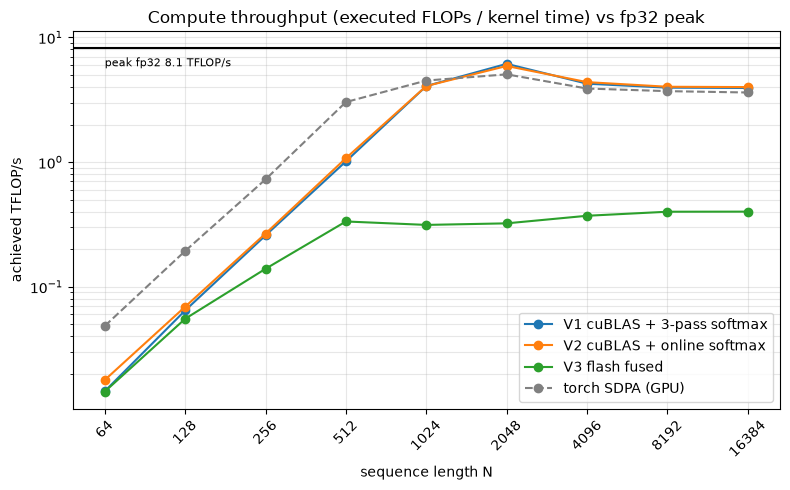

                   version      N      executed  floor x  TFLOP/s  %peak
V1 cuBLAS + 3-pass softmax  16384  558.90 GFLOP   1.017x     3.93  48.2%
V2 cuBLAS + online softmax  16384  559.06 GFLOP   1.017x     3.99  49.0%
            V3 flash fused  16384  595.12 GFLOP   1.083x     0.40   4.9%
          torch SDPA (GPU)  16384  558.99 GFLOP   1.017x     3.61  44.4%


In [11]:
# Chart 5 -- achieved FLOP/s: executed fp32 ops (ncu SASS counters) over
# kernel-only time (CUDA events), against the fp32 ceiling. Counts and
# floor ratios are in the table below.
if cuda.is_available():
    import json
    from pathlib import Path

    prof_path = Path("dram_profile.json")
    prof = json.loads(prof_path.read_text()) if prof_path.exists() else {}
    if not prof or "flops" not in prof["v1"][0]:
        print("dram_profile.json lacks FLOP counters -- regenerate with:")
        print("  sudo .venv/bin/python src/dram_profile.py collect")
    else:
        pnames = {"v1": "V1 cuBLAS + 3-pass softmax", "v2": "V2 cuBLAS + online softmax",
                  "v3": "V3 flash fused", "sdpa": "torch SDPA (GPU)"}
        specs = bench.gpu_specs()
        fig, ax = plt.subplots(figsize=(8, 5))
        for key, rows in prof.items():
            name = pnames[key]
            tmap = dict(zip(SEQ_LENS, ktimes[name]))  # KeyError = stale json
            tflops = [r["flops"] / (tmap[r["n"]] / 1e3) / 1e12 for r in rows]
            ax.plot([r["n"] for r in rows], tflops, marker="o", color=COLORS[name],
                    linestyle="--" if key == "sdpa" else "-", label=name)
        ax.axhline(specs["tflops"], color="k", lw=1.5)
        ax.text(SEQ_LENS[0], specs["tflops"] * 0.72,
                f"peak fp32 {specs['tflops']:.1f} TFLOP/s", fontsize=8)
        ax.set_xscale("log", base=2)
        ax.set_yscale("log")
        ax.set_xticks(SEQ_LENS, SEQ_LENS, rotation=45)
        ax.set_xlabel("sequence length N")
        ax.set_ylabel("achieved TFLOP/s")
        ax.set_title("Compute throughput (executed FLOPs / kernel time) vs fp32 peak")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

        floor = {n: bench.attention_flops(cpu_model, n) for n in SEQ_LENS}
        print(f"{'version':>26} {'N':>6} {'executed':>13} {'floor x':>8} "
              f"{'TFLOP/s':>8} {'%peak':>6}")
        for key, rows in prof.items():
            r = rows[-1]  # largest N
            tf = r["flops"] / (ktimes[pnames[key]][-1] / 1e3) / 1e12
            print(f"{pnames[key]:>26} {r['n']:>6} {r['flops'] / 1e9:>7.2f} GFLOP "
                  f"{r['flops'] / floor[r['n']]:>7.3f}x {tf:>8.2f} "
                  f"{100 * tf / specs['tflops']:>5.1f}%")
else:
    print("No CUDA device -- skipping the throughput chart")

## Conclusion

Chart 1 picked the target — attention is the only step whose share of the
forward pass grows with N, crossing $N \approx 5.5D \approx 2800$ to own
the CPU forward pass — and replacing just that step takes N = 16384
attention from ~7.4 s on the sequential CPU baseline (one thread,
minimum-ISA torch) to ~160–180 ms on the GPU, transfers included
(~40–46×). The surprise is who delivers it: V1 — two cuBLAS matmuls
around a naive three-pass softmax — already ties torch SDPA's math backend
end-to-end (182 vs 183 ms) and beats it kernel-only (141 vs 155 ms, SDPA
pays extra elementwise passes), and V2's one-pass softmax changes almost
nothing at these sizes. Once the GEMMs are library calls, speed is a
solved problem on this card: the composed pipelines run at ~48% of fp32
peak, slightly above SDPA-math itself.

What the ladder still teaches is memory. Chart 3: the unfused pipelines'
DRAM traffic is their N×N-materialisation tax — 88–110× the compulsory
floor at N = 16384 for V1, V2 and SDPA alike — and V2's online softmax is
worth exactly one N² read (1.1 GB less than V1, measured). Chart 4: the
same N×N matrices are the wall — V1, V2 and torch SDPA all OOM at
N = 65536 on the 16 GB card. V3 — the FlashAttention-1 forward: resident
Q tile, one fused kernel, per-tile online softmax that rescales and
renormalises the running output — is the only version that never
materialises the matrix: 3.6 GB of traffic (27× the floor), an O(N)
footprint, and the sole survivor at N = 65536. Its price is the GEMM it
must bring: fusion cannot be composed from library calls — handing cuBLAS
the matmuls means materialising N×N, the very thing fusion exists to
avoid — so V3's matmuls run on numba's scalar fp32 pipeline, ~10× behind
cuBLAS (1.49 s vs 141 ms kernel-only at N = 16384; Chart 5 adds the 1.08×
FLOP-floor cost of its per-tile divides).

That is the project's result, measured from both sides. On this card
(fp32, no tensor-core path) the primitive-level gap — cuBLAS's register
micro-tiles, vectorized loads and software pipelining versus what a scalar
numba kernel can express — is worth ~10× in time, while the
algorithm-level gap — fused versus materialised — is worth 3–4× in bytes
and everything in footprint, but pays time to own its matmuls. Composition
of library calls wins the speed column; fusion wins the memory column and
the right to N = 65536. On fp16 tensor-core hardware, where flash kernels
get library-grade GEMMs *inside* the fusion, the two columns stop trading
off — which is why FlashAttention won in practice. The ladder ends where
the programming model does.